# ResNet-50 Baseline

Week 3 baseline model development for the HiRISE 3820 dataset using `CV6/fold-1`. This notebook uses the reusable PyTorch data-loading and ResNet training utilities in `src/`.

## Experiment Setup

This run follows the structure of Dr. Gao's ResNet example while keeping the project in PyTorch: pretrained ResNet-50, frozen backbone, custom classification head, and fold-1 evaluation.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.hirise_dataset import create_dataloaders
from src.resnet_baseline import fit_resnet, get_device

In [2]:
CV = "CV6"
FOLD = "fold-1"
BATCH_SIZE = 16
IMAGE_SIZE = 224
EPOCHS = 10

device = get_device()
device

device(type='cuda')

## DataLoaders

`CV6/fold-1` corresponds to the six-class HiRISE 3820 fold-1 setup used in the reference examples.

In [3]:
train_loader, test_loader = create_dataloaders(
    cv=CV,
    fold=FOLD,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
)

class_names = train_loader.dataset.classes
num_classes = len(class_names)

len(train_loader.dataset), len(test_loader.dataset), num_classes, class_names

(3053,
 767,
 6,
 ['bright_dune', 'crater', 'dark_dune', 'edge', 'other', 'streak'])

In [4]:
images, labels = next(iter(train_loader))
images.shape, labels.shape

(torch.Size([16, 3, 224, 224]), torch.Size([16]))

## Train ResNet-50

The first baseline trains only the final classification layer while keeping the ImageNet-pretrained ResNet-50 backbone frozen.

In [5]:
model, history, best_metrics = fit_resnet(
    train_loader=train_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    epochs=EPOCHS,
    learning_rate=1e-3,
    weight_decay=1e-4,
    checkpoint_name="resnet50_cv6_fold1_best.pt",
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Jacob/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:04<00:00, 24.9MB/s]


Training:   0%|          | 0/191 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 01/10 | train_loss=0.7765 | train_acc=0.7403 | test_loss=0.5577 | test_acc=0.8383


...

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 09/10 | train_loss=0.3111 | train_acc=0.8935 | test_loss=0.3007 | test_acc=0.9061


Training:   0%|          | 0/191 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 10/10 | train_loss=0.2890 | train_acc=0.8978 | test_loss=0.2911 | test_acc=0.9061


## Training Curves

In [6]:
history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,0.776532,0.740255,0.557685,0.838331
1,2,0.494635,0.843105,0.427407,0.873533
2,3,0.403846,0.859810,0.394037,0.870926
3,4,0.387020,0.869964,0.354084,0.876141
4,5,0.364190,0.877170,0.337409,0.894394
5,6,0.337365,0.885031,0.334223,0.889179
6,7,0.324549,0.888962,0.314211,0.897001
7,8,0.318216,0.888634,0.300392,0.907432
8,9,0.311146,0.893547,0.300650,0.906128
9,10,0.288964,0.897805,0.291098,0.906128


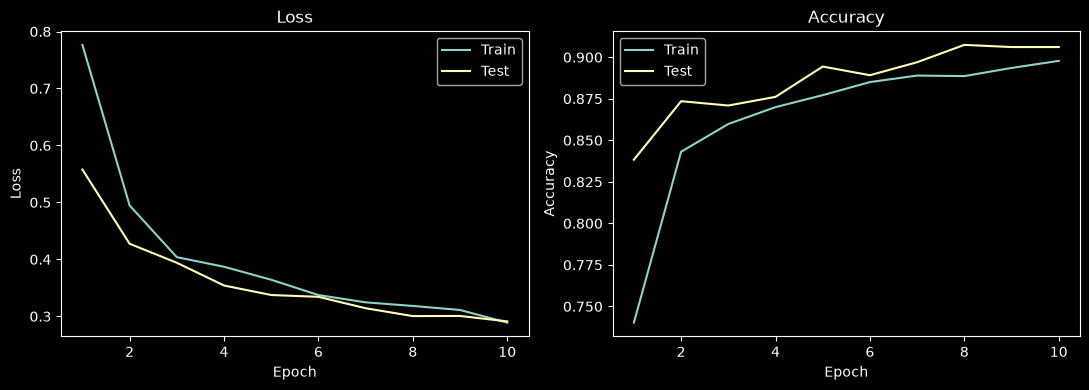

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train")
axes[0].plot(history_df["epoch"], history_df["test_loss"], label="Test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="Train")
axes[1].plot(history_df["epoch"], history_df["test_accuracy"], label="Test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()

## Evaluation

In [8]:
y_true = best_metrics["y_true"]
y_pred = best_metrics["y_pred"]

print(f"Best test loss: {best_metrics['loss']:.4f}")
print(f"Best test accuracy: {best_metrics['accuracy']:.4f}")

Best test loss: 0.3004
Best test accuracy: 0.9074


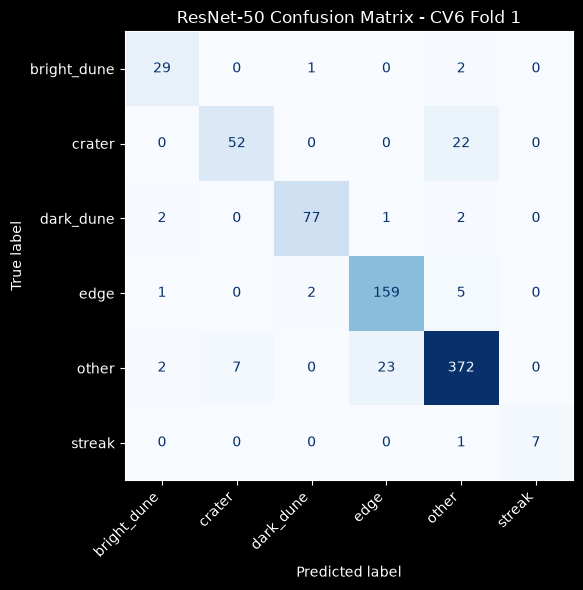

In [9]:
confusion = confusion_matrix(y_true, y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=class_names)

fig, ax = plt.subplots(figsize=(7, 6))
display.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
plt.title("ResNet-50 Confusion Matrix - CV6 Fold 1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In [10]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
    zero_division=0,
)
print(report)

              precision    recall  f1-score   support

 bright_dune     0.8529    0.9062    0.8788        32
      crater     0.8814    0.7027    0.7820        74
   dark_dune     0.9625    0.9390    0.9506        82
        edge     0.8689    0.9521    0.9086       167
       other     0.9208    0.9208    0.9208       404
      streak     1.0000    0.8750    0.9333         8

    accuracy                         0.9074       767
   macro avg     0.9144    0.8826    0.8957       767
weighted avg     0.9081    0.9074    0.9063       767



## Save Metrics

Generated metric files are saved under `outputs/metrics/` and are not tracked by Git.

In [11]:
metrics_dir = PROJECT_ROOT / "outputs" / "metrics"
metrics_dir.mkdir(parents=True, exist_ok=True)

history_df.to_csv(metrics_dir / "resnet50_cv6_fold1_history.csv", index=False)

predictions_df = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
predictions_df.to_csv(metrics_dir / "resnet50_cv6_fold1_predictions.csv", index=False)

print(f"Saved metrics to: {metrics_dir}")

Saved metrics to: C:\Users\Jacob\GitHub\DellSummerResearch\outputs\metrics


## SHAP Preparation Notes

This baseline produces the trained model checkpoint, class names, prediction probabilities, and test predictions needed for later SHAP analysis. SHAP should be applied after baseline performance is stable and representative examples have been selected.

## Baseline Summary and Next Steps

This notebook trained a frozen-backbone ResNet-50 baseline on the HiRISE CV6/fold-1 split. The provided fold structure was preserved: images from `2345-as-training` were used for training, and images from `1-as-test` were used as the held-out evaluation fold.

The model reached a best checkpoint held-out accuracy of 90.74% and a weighted F1-score of 90.63%. The main observed error pattern was crater images being predicted as `other`. A secondary pattern was some `other` images being predicted as `edge`.

These results are sufficient for a Week 3 baseline model. The saved checkpoint can now be used as the starting point for SHAP analysis. The most useful SHAP cases will likely include correctly classified examples, crater images misclassified as `other`, and `other` images misclassified as `edge`.